## Imports

In [18]:
%reload_ext autoreload
%autoreload 2
%matplotlib widget

In [19]:
#Importing all packages
import matplotlib.pyplot as plt
import pandas as pd
import os
# all of the core functions are in the online_gc_utils.py file. if you place your notebook somewhere else, paste this file in the same directory
import FTS_Analysis_GC as fts
from typing import Literal
import numpy as np
import yaml


### Metadata

#### Selecting the experiment from the metadata. This contain the information for the script including experiment_path, reactant concentration, which internal standaard and also the peak intergration values that can be used later.

In [20]:

import os
import yaml
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')

# Load the metadata for the current experiment
current_experiment = 'RCI_AGL_PVL_006_FTS_Co10TiO2'

metadata = all_metadata[current_experiment]

print('Metadata overview')
print('=================')
print('Folder name:         {}'.format(metadata['folder_name']))
print('Experiment:          {}'.format(metadata['experiment_name']))
print('Information:         {}'.format(metadata['description']))
print('                     {}'.format(metadata['notes']))
print('') 
print('Experiment type:     {}'.format(metadata['experiment_type']))
print('Setup:               {}'.format(metadata['setup']))
print('Pretreatment:        {}'.format(metadata['pretreatment']))
print('Catalyst:            {}'.format(metadata['catalyst']['catalyst_code']))
print('')
print(f"Experiment:         {current_experiment}")
print(f"Reactants:          {metadata['reactant_conc']}")
print(f"Internal Standard:  {metadata['IntStand']} ({metadata['ISConc']})")
print(f"Catalyst:           {metadata['catalyst']}")

Metadata overview
Folder name:         20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/
Experiment:          20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/
Information:         FTS with Co10/TiO2 - Steady state,
                     Reduction at 410C, Co10TiO2 catalyst at 20 Barg, 50 hours on stream, 10CO, 20H2, 3Ar, 7N2, 220C, 50Hours,

Experiment type:     FTS
Setup:               FTGC
Pretreatment:        H2, N2
Catalyst:            Co10TiO2

Experiment:         RCI_AGL_PVL_006_FTS_Co10TiO2
Reactants:          {'CO': 0.25, 'CO2': 0.0, 'H2': 0.5, 'Ar': 0.075, 'N2': 0.175, 'He': 0}
Internal Standard:  Ar (0.075)
Catalyst:           {'metal': 'Co', 'support': 'TiO2', 'promoter': None, 'catalyst_code': 'Co10TiO2', 'Co_loading': 10, 'weight': 0.23448}


## Collect and import chromatograms files

### Collect chromatograms:
The collect_chromatogram_files function searches the given experiment directory for chromatogram files (FID, TCD_AuxLeft, TCD_AuxRight), categorizes them into lists, and loads the first file from each type into a DataFrame. This will tell you the number of injections

In [21]:
experiment_path = os.path.join(metadata["root"], metadata["folder_name"])
setup = metadata["setup"]
experiment_name = metadata["experiment_name"]

folder = metadata['root'].replace("\\", '/') + metadata['folder_name']
#logfile_location = folder + metadata['log'] if metadata['log'] else None
#gc_location = folder + metadata['chromatograms'] if metadata['chromatograms'] else None
setup = metadata['setup']

FIDList, AuxLeftList, AuxRightList = fts.collect_chromatogram_filesAll(experiment_path, setup)
print('number of injections = ' + str(len(FIDList)))
FIDList



number of injections = 116


['C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/chromatograms\\FID_28-Apr-2025 16_46.txt',
 'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/chromatograms\\FID_28-Apr-2025 17_07.txt',
 'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/chromatograms\\FID_28-Apr-2025 17_29.txt',
 'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/chromatograms\\FID_28-Apr-2025 17_50.txt',
 'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_

### Combine chromatograms:
The chromatogram function processes a list of chromatogram files (e.g., FID, AuxLeft, AuxRight), aligns them based on time relative to the earliest FID file, and returns a combined DataFrame saved as a CSV file. This can take a while depending on the amount of injections and computer power. Aprox 60 seconds
You only have to do this once to load your data

[INFO] Data is already loaded: FID_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/.
[INFO] Data is already loaded: TCD_AuxLeft_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/.
[INFO] Data is already loaded: TCD_AuxRight_total.csv exists in C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/20250428-AGL-PVL-Co10TiO2-20Bar-10CO_20H2_3Ar_7N2-410Red-220FTS/.
Date/time of the GC start: 2025-04-28 16:46:00
Peak Name   | Integration Limits   | Two Point Baseline
------------------------------------------------------
C1         | [1.84, 1.895]        | No
C2         | [1.895, 2.0]         | No
C3         | [2.0, 2.26]          | Yes
C4         | [2.32, 2.73]    

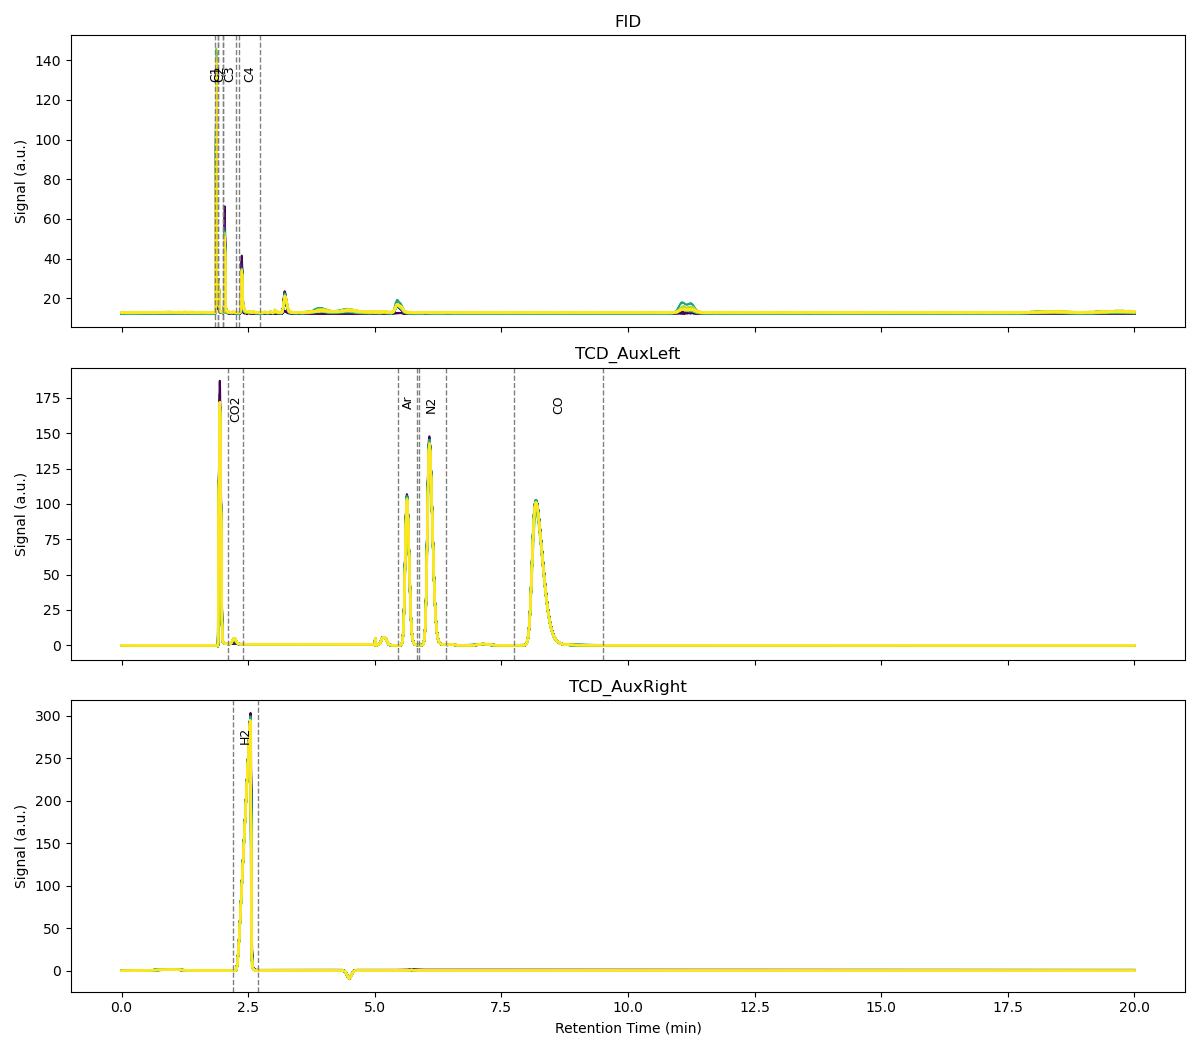

In [32]:
# Process FID
FIDDF1, datetime_start = fts.chromatogramAll(file_list=FIDList, setup=setup, output_path=experiment_path, output_name='FID_total.csv')
# Process TCD_AuxLeft detectors
AuxLeftDF1, datetime_start = fts.chromatogramAll(file_list=AuxLeftList, setup=setup, output_path=experiment_path, output_name='TCD_AuxLeft_total.csv')
# Process TCD_AuxRight detectors
AuxRightDF1, datetime_start = fts.chromatogramAll(file_list=AuxRightList, setup=setup, output_path=experiment_path, output_name='TCD_AuxRight_total.csv')

print("Date/time of the GC start: " + str(datetime_start))

#Plotting the chromatograms: Plots chromatograms from multiple channels over a specified TOS (Time on Stream) range with color mapping.
def convert_peak_dict_to_list(peak_dict): # Only needed if you have metadata.yaml file
    return [[name, values["range"], values["two_point_baseline"]] for name, values in peak_dict.items()]
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')
metadata = all_metadata[current_experiment]
FID_peaks = convert_peak_dict_to_list(metadata["FID_peaks"]) # Only needed if you have metadata.yaml file
TCDLeft_peaks = convert_peak_dict_to_list(metadata["TCDLeft_peaks"]) # Only needed if you have metadata.yaml file
TDCRight_peaks = convert_peak_dict_to_list(metadata["TCDRight_peaks"]) # Only needed if you have metadata.yaml file
peak_names = [peak[0] for peak in FID_peaks + TCDLeft_peaks +TDCRight_peaks]
peak_dict = { 'FID': FID_peaks, 'TCD_AuxLeft': TCDLeft_peaks, 'TCD_AuxRight': TDCRight_peaks }
print("Peak Name   | Integration Limits   | Two Point Baseline")
print("------------------------------------------------------")
for peak in FID_peaks + TCDLeft_peaks + TDCRight_peaks:
    name = peak[0]
    limits = peak[1]
    baseline = "Yes" if peak[2] else "No"
    print(f"{name:<10} | {str(limits):<20} | {baseline}")

fts.plot_chromatogram(
    df_list=[FIDDF1, AuxLeftDF1, AuxRightDF1],
    labels=['FID', 'TCD_AuxLeft', 'TCD_AuxRight'],
    tos_range=(20,2100), # Write None all injections, or (start, end) in minutes
    show_legend=None,
    show_peaks=True,
    peak_dict=peak_dict,
    colormap='viridis'
)

### Baseline corrections: 
The following code is used to correct the baseline of the chromatograms. 

In [23]:
FIDDF_corr = FIDDF1.apply(lambda col: fts.baseline_correct_column(col, FIDDF1.index, 0.6, 0.9))
FIDDF_corr.head(5) 


,0.0,21.0,43.0,64.0,85.0,106.0,128.0,149.0,170.0,192.0,...,2258.0,2279.0,2300.0,2322.0,2343.0,2364.0,2385.0,2407.0,2428.0,2449.0
Time,,,,,,,,,,,,,,,,,,,,,
0.000000,0.010741,-0.025763,0.006240,0.020021,-0.021795,-0.013784,0.033028,-0.067065,0.103230,0.103148,...,-0.089610,0.029801,0.017913,0.082945,-0.450811,-0.451447,-0.563173,-0.434253,-0.496888,-0.384444
0.000667,0.027695,-0.049521,0.010034,0.015610,0.008469,0.007005,0.055210,-0.048789,0.064378,0.114632,...,-0.092924,-0.001872,0.001705,0.073437,-0.415757,-0.458921,-0.544447,-0.426848,-0.491530,-0.402556
0.001333,0.018888,-0.047658,-0.025890,0.003595,-0.006678,-0.001812,0.034937,-0.062646,0.094313,0.087234,...,-0.090269,0.007552,-0.046801,0.080915,-0.423172,-0.475872,-0.550477,-0.436951,-0.473437,-0.409264
0.002000,0.014506,-0.079470,-0.010161,0.011805,0.025529,-0.039569,0.032401,-0.065168,0.085394,0.097428,...,-0.125479,-0.007930,-0.044122,0.080215,-0.408314,-0.479940,-0.536443,-0.458494,-0.470082,-0.421316
0.002667,0.040263,-0.040779,-0.000703,0.006126,0.021736,-0.028880,0.003953,-0.064544,0.095575,0.121001,...,-0.151336,0.016983,-0.052857,0.087010,-0.460908,-0.489422,-0.549139,-0.536955,-0.496888,-0.427339


## Logfile import
Reading and combining the logfiles in .txt format of the experiment. Then extracting only the neccesary columns like Pressure, Temperature of the reactor, and gas flows. This is then plotted over date/time or over TOS. When the datetime_start is defined, the 0 indicates the start of the GC injections. The read_logfile function reads and combines reactor logfiles from a specified folder, filters the data to include only when the reactor is active (Valve 9 = 1), plots pressure and oven temperature over time, plots selected gas flows (e.g., H₂, CO), and returns the cleaned and processed data as a DataFrame.

Multiple logfiles found! Combining them...


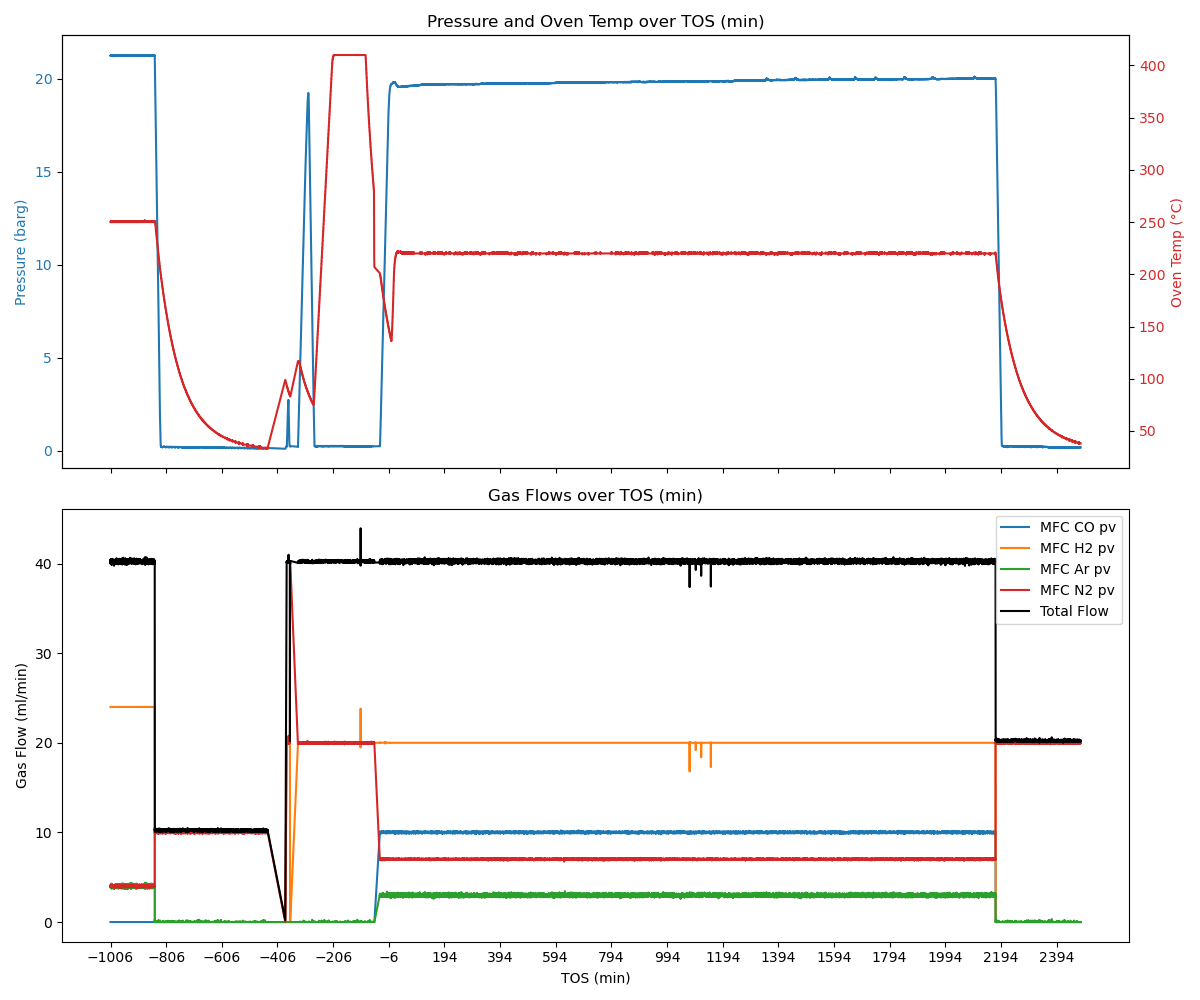

In [24]:
log_df, x_axis, gas_columns, plot_against = fts.read_logfile(
    experiment_path,
    gases_to_plot=['CO', 'H2', 'Ar', 'N2'], 
    datetime_start=datetime_start,  
    plot_against='TOS',  # or 'TOS' for time on stream
)
    # --- Plotting ---
fig, (axP, gasses) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axP.plot(x_axis, log_df['Pressure R1'], color='tab:blue', label='Pressure (barg)')
axP.set_ylabel('Pressure (barg)', color='tab:blue')
axP.tick_params(axis='y', labelcolor='tab:blue')

axT = axP.twinx()
axT.plot(x_axis, log_df['Oven PV'], color='tab:red', label='Oven Temp (°C)')
axT.set_ylabel('Oven Temp (°C)', color='tab:red')
#temp.set_ylim(150, 250)  # Adjust as needed
axT.tick_params(axis='y', labelcolor='tab:red')

axP.set_title(f"Pressure and Oven Temp over {'TOS (min)' if plot_against=='TOS' else 'Time'}")

for gas_col in gas_columns:
    gasses.plot(x_axis, log_df[gas_col], label=gas_col)

gasses.plot(x_axis, log_df['Total Flow'], label='Total Flow', color='black')
gasses.set_ylabel('Gas Flow (ml/min)')
gasses.set_xlabel('TOS (min)' if plot_against.lower() == 'tos' else 'Date/Time')
gasses.set_xticks(np.arange(log_df['TOS'].min(), log_df['TOS'].max() + 1, 200))  # Adjust as needed
#gasses.set_xlim(1525, 3325)
gasses.legend(loc='upper right')
gasses.set_title(f"Gas Flows over {'TOS (min)' if plot_against=='TOS' else 'Time'}")

plt.tight_layout()
plt.show()

## Intergration and data analysis

### Intergration:
 Do intergrations based on the intergration limits set in FID_peaks, TCDLeft_peaks and TCDRight_peaks. Parse logfile with the intergration values of the reactants and products based on the timestamp of the injection into the GC. and plotting the raw areas against time on steam

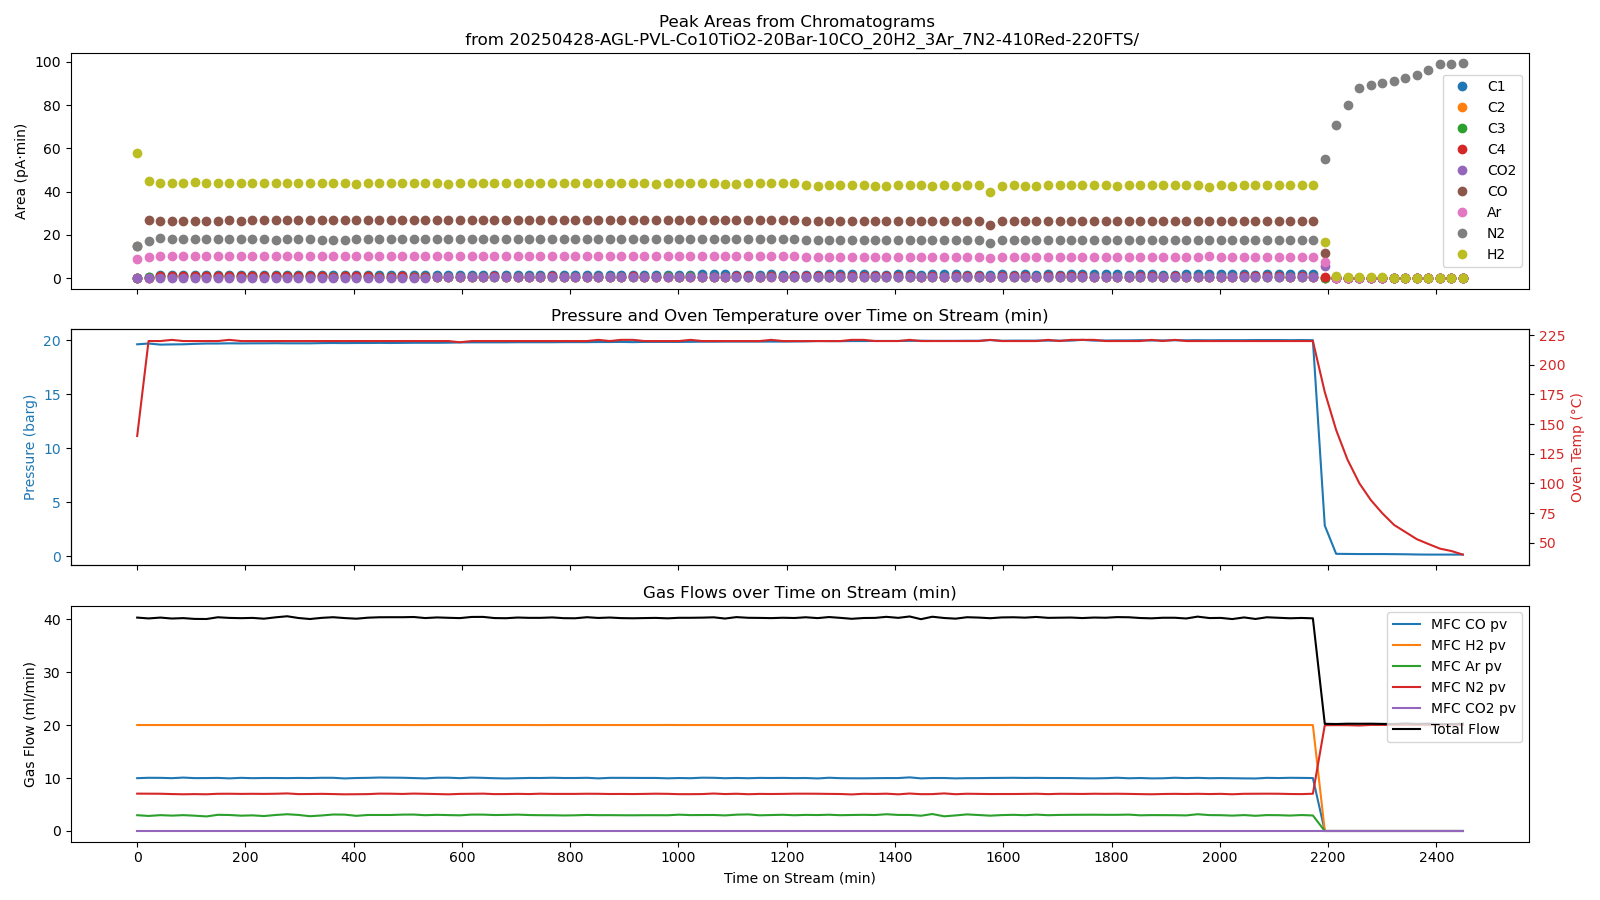

In [25]:
area_FIDDF = fts.integrate_named_peaks(FIDDF_corr, FID_peaks)
area_AuxLeft = fts.integrate_named_peaks(AuxLeftDF1, TCDLeft_peaks)
area_AuxRight = fts.integrate_named_peaks(AuxRightDF1, TDCRight_peaks)
area_totalDF = pd.concat([area_FIDDF, area_AuxLeft, area_AuxRight], axis=1)
area_totalDF.index.name = "TOS"
log_area_df = fts.parse_logfile_areas(area_totalDF, log_df)
log_area_df.to_excel(experiment_path + '/log_rawareas.xlsx')
fts.plot_comined_overview(
    combined_df=log_area_df,
    experiment_name=experiment_name,
    integration_gases=peak_names,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv', 'MFC CO2 pv'],
    plot_against='TOS'  # or 'datetime'
)


### Area to concentration factor
Converting the area into concentration factor by using the correction factor. This correciton is done by dividing the area of the peak by the correction factor of that corresponding peak. The value is a factor of the total gas flow including reactants, products and inert

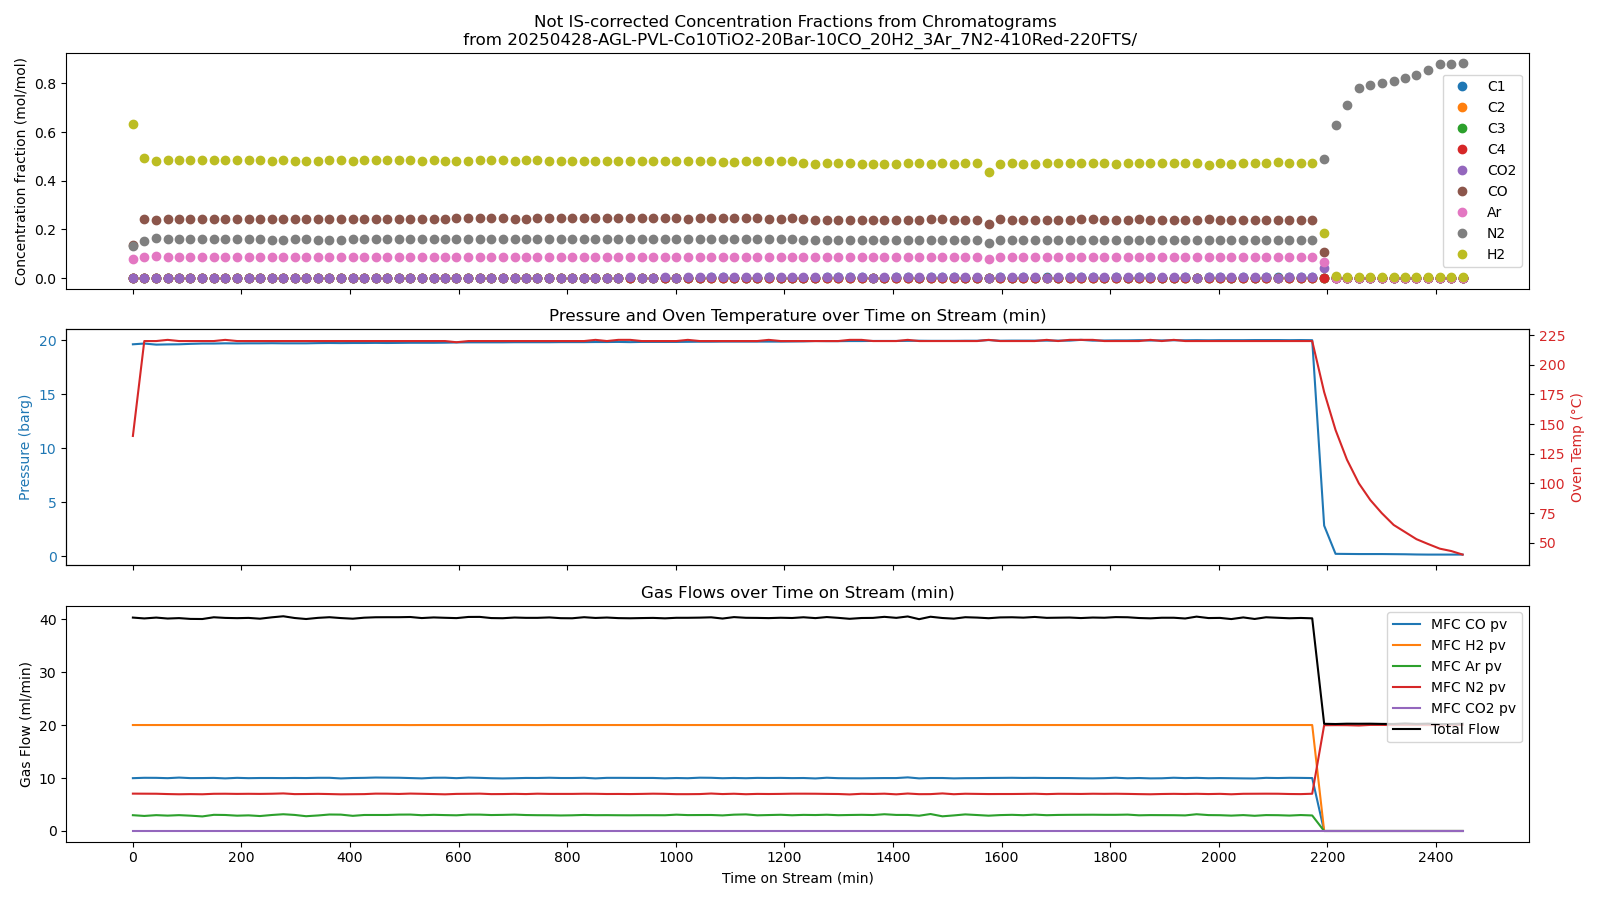

In [26]:
#Correction factors for the FTS setup for 40 ml/min of total gas flow
# Date: 01 april 2025
C1 = 705.88
FTCorrectionFactorsDict = {
'C1' : C1,
'C2' : C1 * 2,
'C3' : C1 * 3,
'C4' : C1 * 4,
'CO2': 134.56,
'CO' : 109.34,
'Ar' : 114.48,
'N2' : 112.57,
'H2' : 91
}

Amounts_logDF = pd.DataFrame(index=log_area_df.index)
Amounts_logDF = log_area_df.copy()
NoIntegrationValues = []
for name in peak_names:
    if name in log_area_df.columns:
        if name in FTCorrectionFactorsDict:
            Amounts_logDF[name] = log_area_df[name] / FTCorrectionFactorsDict[name]
        else:
            NoIntegrationValues.append(name)
    else:
        print(f"Warning: Peak '{name}' not found in log_area_df.")
Amounts_logDF.to_excel(experiment_path + '/Amounts_with_logdata_and_corrected_peaks.xlsx')

# --- Optional: Report missing correction factors ---
if NoIntegrationValues:
    print("No correction factor found for:", NoIntegrationValues)
    
fts.plot_comined_overview(
    combined_df=Amounts_logDF,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv', 'MFC CO2 pv'],
    experiment_name=experiment_name,
    integration_gases=peak_names,
    plot_against='TOS',
    #xlim=(1000, 3200), # Adjust TOS x-axis limits as needed
    #ax1_ylim=(0, 0.01), # Adjust y-axis limits for chromatogram results as needed
    ax1_label='Concentration fraction (mol/mol)',
    ax1_title='Not IS-corrected Concentration Fractions from Chromatograms'
)

### Internal standaard correction:
The GasContractionFactor is calculated for each injection by dividing the internal standaard concentration in the GC by the internal standaard concentration before the reactor (from your MFC's). 
C5+ selectivity can be calculated by substracting the unconverted CO and all the C1-C4 and CO2 product from the incoming CO. 
Only valid when assuming complete carbon balance (no coke formation)

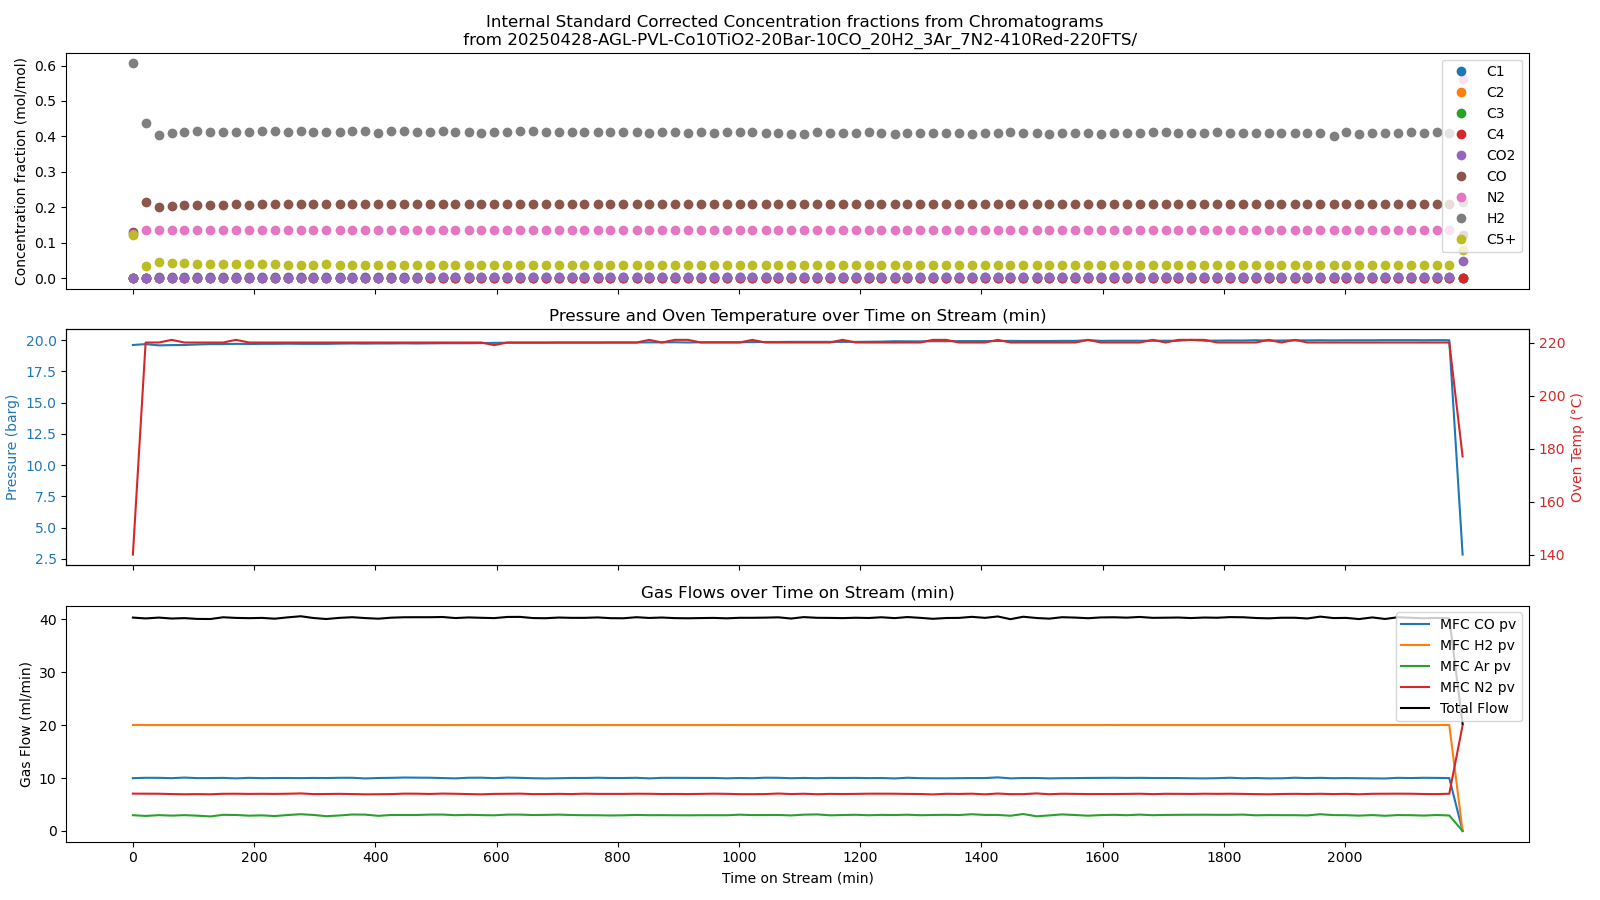

In [27]:
ReactantConc = metadata['reactant_conc']
IntStand = metadata['IntStand']
ISConc = metadata['ISConc']
is_logDF = Amounts_logDF.copy()
is_logDF['GasContractionFactor'] = is_logDF[IntStand] / ISConc # Compute Gas Contraction Factor
is_logDF = is_logDF[is_logDF['GasContractionFactor'] > 0.1] #Filter out rows with very low internal standard signal
for col in peak_names: #Apply internal standard correction only to peak_names
    if col in is_logDF.columns:
        is_logDF[col] = is_logDF[col] / is_logDF['GasContractionFactor']
is_logDF = is_logDF.drop(columns=['GasContractionFactor', IntStand])
is_logDF['C5+'] = ReactantConc['CO'] - is_logDF['C1'] - is_logDF['C2'] - is_logDF['C3'] - is_logDF['C4'] - is_logDF['CO2'] - is_logDF['CO']
is_logDF.to_excel(experiment_path + '/Amounts_iscorr+log_factor_between_0and1.xlsx')

fts.plot_comined_overview(
    combined_df=is_logDF,
    gas_flow_columns=['MFC CO pv', 'MFC H2 pv', 'MFC Ar pv', 'MFC N2 pv'],
    experiment_name=experiment_name,
    integration_gases=peak_names + ['C5+'],
    plot_against='TOS',
    #xlim=(1600, 3400), # Adjust TOS x-axis limits as needed
    #ax1_ylim=(0, 0.09), # Adjust y-axis limits for chromatogram results as needed
    ax1_label='Concentration fraction (mol/mol)',
    ax1_title='Internal Standard Corrected Concentration fractions from Chromatograms'
)


### Conversion calculation

Calculate reactant and/or product conversion. This is based on the following formula conversion = ((set_concentration-reactant_amount)/set_concentration)*100. The values are taken from the internal standard corrected concentation fraction. Adjust the figure accordingly to better see your conversion

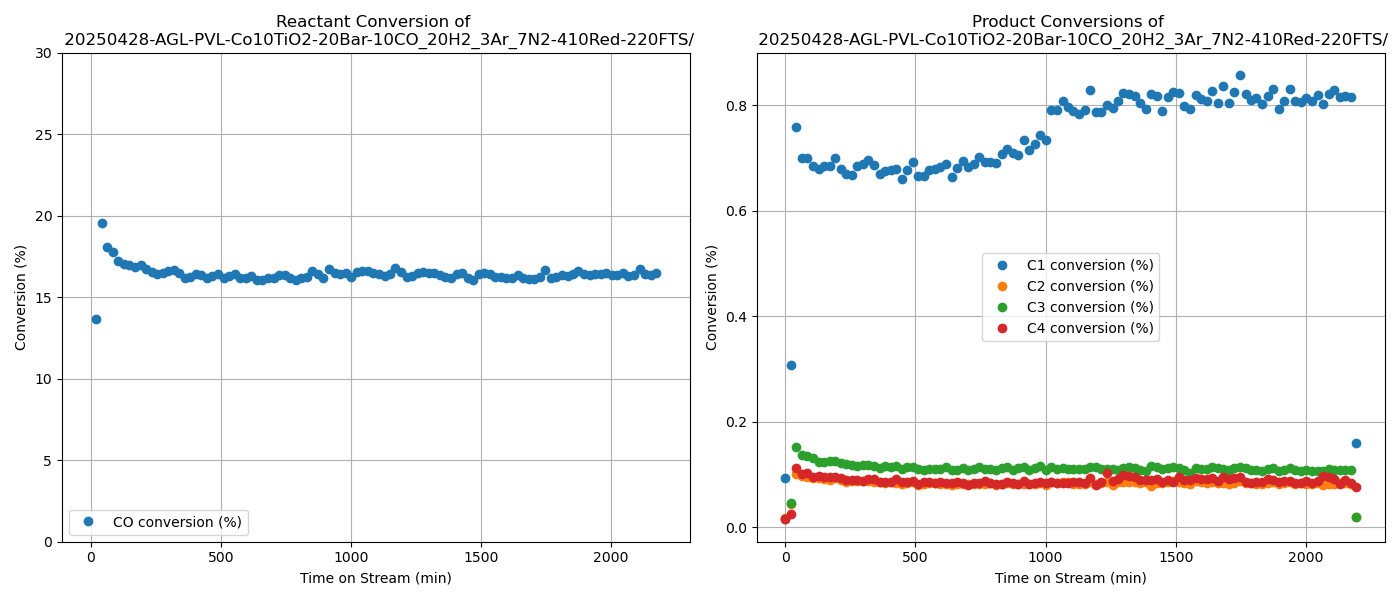

In [28]:
Reactant = "CO"
products = ["C1", "C2", "C3", "C4"]

# Calculate conversions
ReactantConversion = fts.calculate_conversion_based_on_reactant(is_logDF, Reactant, ReactantConc[Reactant])
conversion_df = fts.calculate_product_conversions(is_logDF, products, ReactantConc[Reactant])

# Combine into one DataFrame
ConversionsDF = pd.concat([ReactantConversion, conversion_df], axis=1)

# Save to Excel
ConversionsDF.to_excel(experiment_path + "/all_conversions.xlsx")


# -------------------------
# Plotting: side by side
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

# Plot reactant conversion
axes[0].plot(ReactantConversion.index, ReactantConversion, linestyle="", marker="o", label=ReactantConversion.name)
axes[0].set_title(f"Reactant Conversion of \n {experiment_name}")
axes[0].set_xlabel("Time on Stream (min)")
axes[0].set_ylabel("Conversion (%)")
axes[0].set_ylim(0, 30)
axes[0].legend()
axes[0].grid(True)

# Plot product conversions
for col in conversion_df.columns:
    axes[1].plot(conversion_df.index, conversion_df[col], linestyle="", marker="o", label=col)
axes[1].set_title(f"Product Conversions of \n {experiment_name}")
axes[1].set_xlabel("Time on Stream (min)")
axes[1].set_ylabel("Conversion (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Cobalt Time Yield conversion

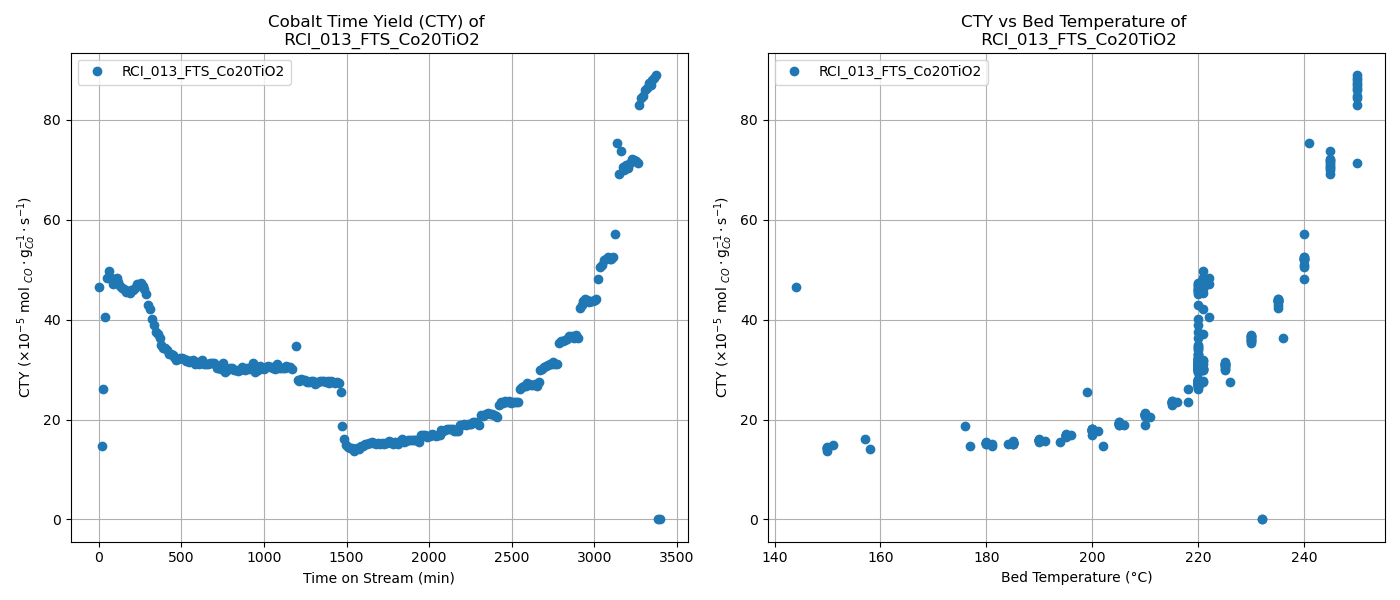

In [29]:
processed_data_path = r'C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data/'
all_metadata = fts.load_experiment_metadata(r'C:/Users/6855245/OneDrive - Universiteit Utrecht/PhD/Results/FTS catalytic tests/Processed_data/raw_data/FTS_Robin_metadata.yaml')
gas_constant = 0.083145  # L·bar/(K·mol)

# Getting the desired experiment data
experiment = "RCI_013_FTS_Co20TiO2" # Or use current_experiment to load the same experiment as before
mass_Co = all_metadata[experiment]["catalyst"]["weight"] * all_metadata[experiment]["catalyst"]["Co_loading"]/100 # weight catalyst in reactor [gram] * wt% Co 
experiment_path1 = os.path.join(all_metadata[experiment]["root"], all_metadata[experiment]["folder_name"])
data_Log = pd.read_excel(experiment_path1 + '/Amounts_iscorr+log_factor_between_0and1.xlsx', index_col=0)
conversions = pd.read_excel(experiment_path1 + '/all_conversions.xlsx', index_col=0)
data = pd.concat([data_Log, conversions], axis=1)

# Calculate CO_in (molCO/s) and CTY (molCO*gCo^-1*s^-1) for each injection 
data['CO_in (molCO/s)'] = (((data['Pressure R1']+1)*(data['MFC CO pv']/1000))/(gas_constant*(data['Oven PV']+273.15))) / 60  # mol/s
data['CTY'] = data['CO_in (molCO/s)'] * (data['CO conversion (%)']/100) / mass_Co # (molCO*gCo^-1*s^-1)
data['CTY_scaled'] = data['CTY']*100000 # (x10^(-5) molCO*gCo^-1*s^-1)
data.to_excel(experiment_path1 + f"/all_results_{experiment}.xlsx")

# -------------------------
# Plotting: side by side
# -------------------------
fig, (axTime, axTemp) = plt.subplots(1, 2, figsize=(14, 6))
# Plot CTY over TOS
axTime.plot(data.index, data['CTY_scaled'], linestyle="", marker="o", label=experiment)
axTime.set_title(f"Cobalt Time Yield (CTY) of \n {experiment}")
#axTime.set_ylim(0, 120)
axTime.set_xlabel("Time on Stream (min)")
axTime.set_ylabel(r"CTY ($\times 10^{-5}$ mol $_{CO}\cdot$g$_{Co}^{-1}\cdot$s$^{-1}$)")
axTime.legend()
axTime.grid(True)

# Plot CTY over temperature
axTemp.plot(data['Oven PV'], data['CTY_scaled'], linestyle="", marker="o", label=experiment)
axTemp.set_title(f"CTY vs Bed Temperature of \n {experiment}")
axTemp.set_xlabel("Bed Temperature (°C)")
axTemp.set_ylabel(r"CTY ($\times 10^{-5}$ mol $_{CO}\cdot$g$_{Co}^{-1}\cdot$s$^{-1}$)")
axTemp.legend()
axTemp.grid(True)

plt.tight_layout()
plt.show()


## Multiple experiments together

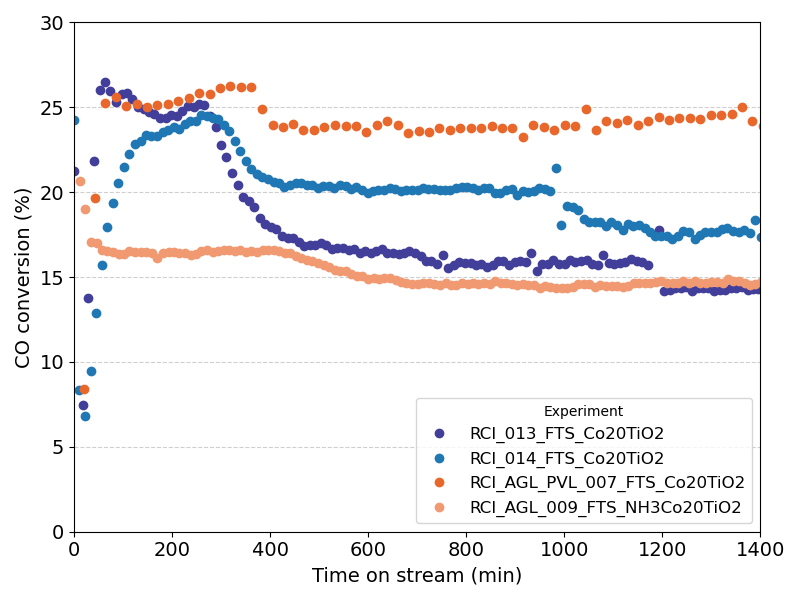

c:\users\6855245\onedrive - universiteit utrecht\phd\results\fts catalytic tests\fts_gc_analysisrc\FTS_Analysis_GC\FTS_Analysis_GC.py:672: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


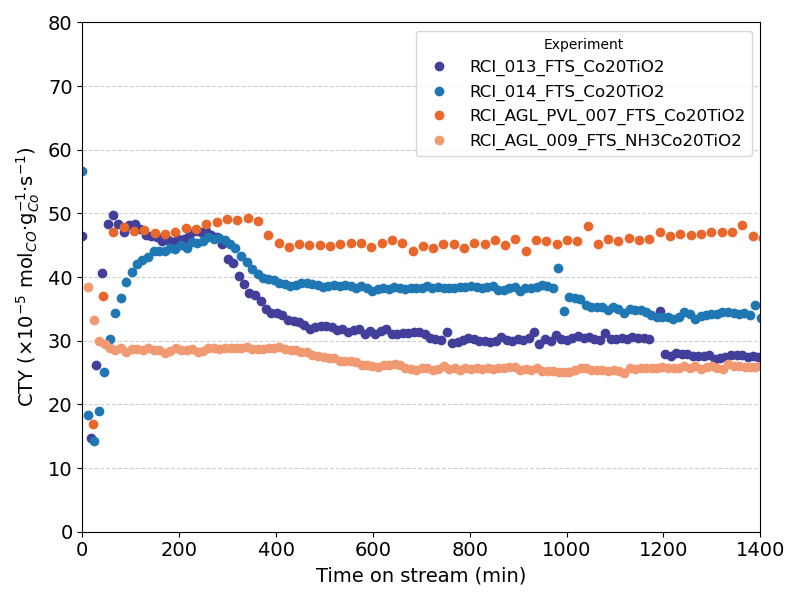

In [30]:
processed_data_path = r"C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Results\FTS catalytic tests\Processed_data\raw_data"
metadata_path = os.path.join(processed_data_path, "FTS_Robin_metadata.yaml")

experiments_to_plot = [
    #"RCI_AGL_PVL_006_FTS_Co10TiO2",
    #"RCI_AGL_012_FTS_NH3Co10TiO2",
    'RCI_013_FTS_Co20TiO2',
    'RCI_014_FTS_Co20TiO2',
    "RCI_AGL_PVL_007_FTS_Co20TiO2",
    "RCI_AGL_009_FTS_NH3Co20TiO2",
]

colors = {
    "RCI_013_FTS_Co20TiO2": "#423f9b",
    "RCI_AGL_012_FTS_NH3Co10TiO2": "#6faad1",
    "RCI_AGL_PVL_007_FTS_Co20TiO2": "#E9672B",
    "RCI_AGL_009_FTS_NH3Co20TiO2": "#F19971",
}


bar_colors = ["#2B5777", "#6faad1", "#E9672B", "#F19971"]
# --- Plot CO conversion ---
fts.plot_experiment_results(
    metadata_path=metadata_path,
    experiments=experiments_to_plot,
    column="CO conversion (%)",
    ylabel="CO conversion (%)",
    xlim=(0, 1400),
    ylim=(0, 30),
    colors=colors
)

plt.savefig(r"C:\Users\6855245\OneDrive - Universiteit Utrecht\PhD\Poster\poster figures svg\CTY_comparison.svg", dpi=300)
# --- Plot CTY ---
fts.plot_experiment_results(
    metadata_path=metadata_path,
    experiments=experiments_to_plot,
    column="CTY_scaled",
    ylabel=r"CTY ($\times 10^{-5}$ mol$_{CO}$·g$_{Co}^{-1}$·s$^{-1}$)",
    xlim=(0, 1400),
    ylim=(0,80),
    colors=colors
)


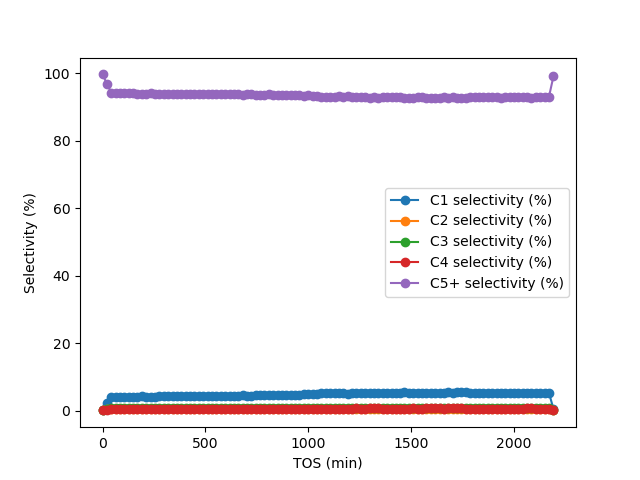

In [31]:
def calculate_selectivity(df, products):
    """
    Calculate product selectivity (C1, C2, ..., C5+).

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns for product molar flows (mol/min or mol% basis).
    products : list
        Product column names, e.g. ["C1", "C2", "C3", "C4", "C5+"].

    Returns
    -------
    pd.DataFrame with selectivities (%).
    """
    product_flows = df[products]
    total_carbon_flow = product_flows.sum(axis=1)
    selectivity_df = (product_flows.div(total_carbon_flow, axis=0)) * 100
    selectivity_df.columns = [f"{p} selectivity (%)" for p in products]
    return selectivity_df

products = ["C1", "C2", "C3", "C4", "C5+"]
selectivity_df = calculate_selectivity(is_logDF, products)

# Save or plot
selectivity_df.to_excel(experiment_path + "/selectivities.xlsx")
selectivity_df.plot(marker="o")
plt.ylabel("Selectivity (%)")
plt.xlabel("TOS (min)")
plt.show()